<a href="https://colab.research.google.com/github/034adarsh/Stock-Price-Prediction-Using-LSTM/blob/main/LSTM_Improved_model(diff_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Important required libraries

---



In [47]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

# Define start day to fetch the dataset from the yahoo finance library

---



In [48]:


START = "2000-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [49]:
data = load_data('TCS.NS')
df=data
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2002-08-12,25.828411,26.023588,25.194085,25.194085,212976
1,2002-08-13,25.478720,26.275694,25.291676,25.860942,153576
2,2002-08-14,23.722120,25.535637,23.242309,25.535637,822776
3,2002-08-15,23.722120,23.722120,23.722120,23.722120,0
4,2002-08-16,23.665195,24.722404,23.258577,23.600138,811856


In [50]:
df = df.drop(['Date'], axis = 1)
df.head()

C:\Users\amarj\AppData\Local\Temp\ipykernel_21108\3502562368.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis = 1)


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,25.828411,26.023588,25.194085,25.194085,212976
1,25.478720,26.275694,25.291676,25.860942,153576
2,23.722120,25.535637,23.242309,25.535637,822776
3,23.722120,23.722120,23.722120,23.722120,0
4,23.665195,24.722404,23.258577,23.600138,811856


# Visualizing Closing Price

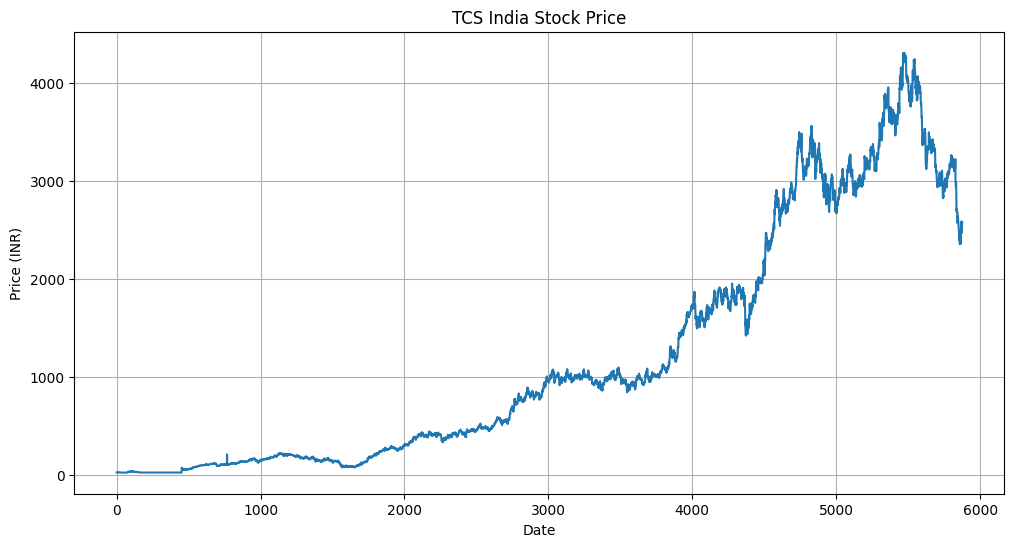

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("TCS India Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

In [52]:
df

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,25.828411,26.023588,25.194085,25.194085,212976
1,25.478720,26.275694,25.291676,25.860942,153576
2,23.722120,25.535637,23.242309,25.535637,822776
3,23.722120,23.722120,23.722120,23.722120,0
4,23.665195,24.722404,23.258577,23.600138,811856
...,...,...,...,...,...
5871,2589.000000,2605.000000,2531.100098,2554.000000,5628261
5872,2524.300049,2565.800049,2501.100098,2565.800049,10480239
5873,2472.600098,2504.899902,2470.000000,2489.899902,3739587


# Plotting moving averages of 100 day

---



In [53]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
5871,2910.415508
5872,2905.156011
5873,2899.376567
5874,2894.457444


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

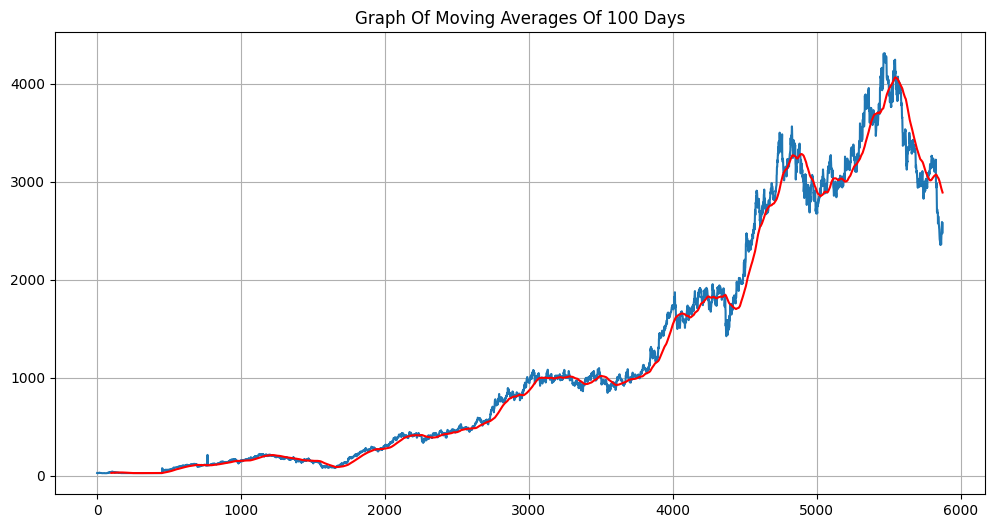

In [54]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.grid(True)
plt.title('Graph Of Moving Averages Of 100 Days')

# Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

---



In [55]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
5871,2982.343784
5872,2978.270088
5873,2973.880844
5874,2970.108374


Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

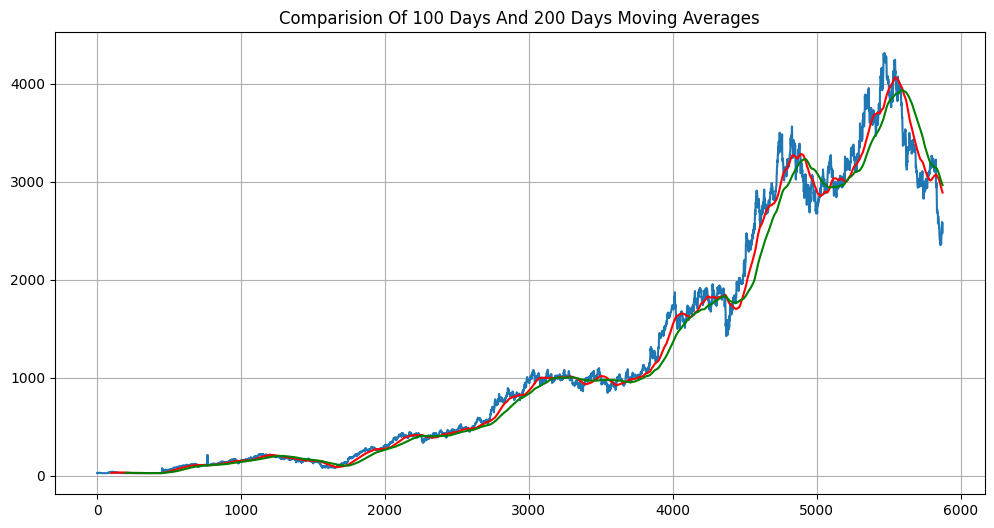

In [56]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.grid(True)
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

In [57]:
df.shape

(5876, 5)

# Spliting the dataset into training (70%) and testing (30%) set

In [58]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(4113, 6)
(1763, 6)


In [59]:
train.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2002-08-12,25.828411,26.023588,25.194085,25.194085,212976
1,2002-08-13,25.478720,26.275694,25.291676,25.860942,153576
2,2002-08-14,23.722120,25.535637,23.242309,25.535637,822776
3,2002-08-15,23.722120,23.722120,23.722120,23.722120,0
4,2002-08-16,23.665195,24.722404,23.258577,23.600138,811856


In [60]:
test.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
4113,2019-02-22,1604.597656,1608.222386,1587.473797,1597.556414,2271955
4114,2019-02-25,1654.177612,1658.218980,1608.639066,1610.305617,2934880
4115,2019-02-26,1698.799194,1704.173884,1643.428063,1653.219052,6453309
4116,2019-02-27,1714.965088,1729.005664,1684.883749,1699.882714,4732082
4117,2019-02-28,1652.760742,1726.005803,1647.886099,1716.548041,8454295


# Using MinMax scaler for normalization of the dataset

---



In [61]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [62]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [63]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.00220264],
       [0.00256388],
       [0.00238766],
       ...,
       [0.87778019],
       [0.85295415],
       [0.85284136]], shape=(4113, 1))

In [64]:
x_train = []
y_train = [] 

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train) 

In [65]:
x_train.shape

(4013, 100, 1)

# ML Model (LSTM)

---



In [66]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [67]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

C:\Users\amarj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

---



In [69]:
import tensorflow as tf
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model.fit(x_train, y_train,epochs = 100)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - loss: 0.0137 - mean_absolute_error: 0.0701
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 203ms/step - loss: 0.0033 - mean_absolute_error: 0.0375
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - loss: 0.0028 - mean_absolute_error: 0.0337
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 27s 210ms/step - loss: 0.0034 - mean_absolute_error: 0.0368
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 28s 222ms/step - loss: 0.0027 - mean_absolute_error: 0.0324
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 31s 247ms/step - loss: 0.0024 - mean_absolute_error: 0.0305
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - loss: 0.0025 - mean_absolute_error: 0.0312
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 209ms/step - loss: 0.0026 - mean_absolute_error: 0.0320
Epoch 9/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 28s 218ms/step - loss: 0.0022 - mean_absolute_error: 0.0296
Epoch 10/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 29s 233ms/step - loss: 0.0023 - mean_absolute_err

In [70]:
model.save('keras_model.h5')

In [71]:
test_close.shape

(1763, 1)

In [72]:
past_100_days = pd.DataFrame(train_close[-100:])

In [73]:
test_df = pd.DataFrame(test_close)

**Defining the final dataset for testing by including last 100 coloums of the training dataset to get the prediction from the 1st column of the testing dataset.**

---


In [74]:
# final_df = past_100_days.append(test_df, ignore_index = True)
import pandas as pd

final_df = pd.concat([past_100_days, test_df], ignore_index=True)

In [75]:
final_df.head()

,0
0,1777.232959
1,1807.186383
2,1817.890015
3,1867.177077
4,1789.429987


In [76]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.14161403],
       [0.15167563],
       [0.15527106],
       ...,
       [0.38100459],
       [0.38503548],
       [0.40858267]], shape=(1863, 1))

In [77]:
input_data.shape

(1863, 1)

# Testing the model

---



In [78]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [79]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(1763, 100, 1)
(1763,)


# Making prediction and plotting the graph of predicted vs actual values

---



In [80]:
# Making predictions

y_pred = model.predict(x_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step


In [81]:
y_pred.shape

(1763, 1)

In [82]:
y_test

array([0.08125923, 0.08554179, 0.09995676, ..., 0.38100459, 0.38503548,
       0.40858267], shape=(1763,))

In [83]:
y_pred

array([[0.19207792],
       [0.19400464],
       [0.19484167],
       ...,
       [0.40820998],
       [0.40969306],
       [0.41126913]], shape=(1763, 1), dtype=float32)

In [84]:
scaler.scale_

array([0.00033591])

In [85]:
scale_factor = 1/0.00041967
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

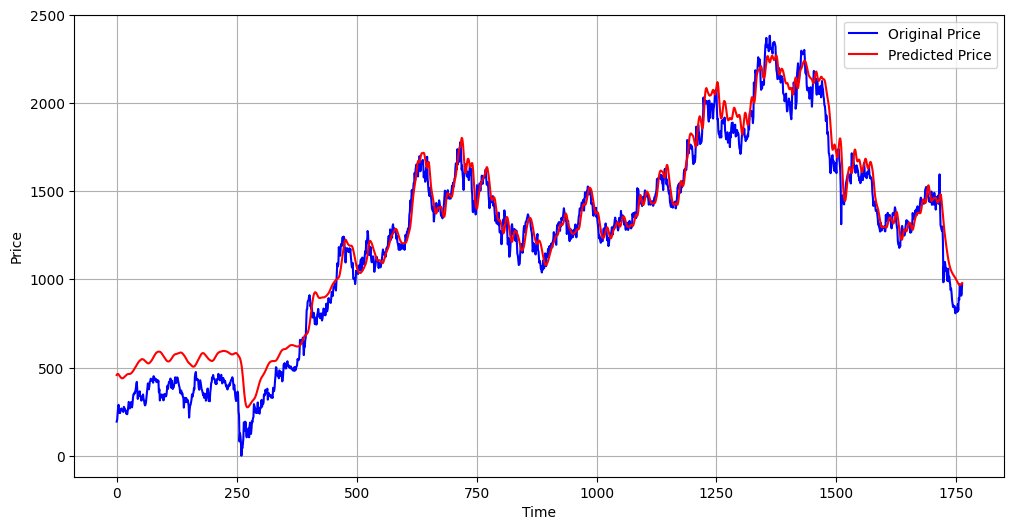

In [86]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Model evaluation

Calculation of mean absolute error

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae_percentage = (mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))
errors = np.abs(y_test - y_pred)
# Actual values
actual = y_test

# Predicted values
predicted = y_pred
# Plot
plt.scatter(actual, errors)
plt.xlabel('Actual Values')
plt.ylabel('Absolute Error')
plt.title(f'MAE: {mae:.2f}')
plt.axhline(y=mae, linestyle='--')  # average error line
plt.show()

Mean absolute error on test set: 7.00%


Calculation of R2 score

In [88]:
from sklearn.metrics import r2_score

# Actual values
actual = y_test

# Predicted values
predicted = y_pred

# Calculate the R2 score
r2 = r2_score(actual, predicted)

print("R2 score:", r2)

R2 score: 0.9602525785571839


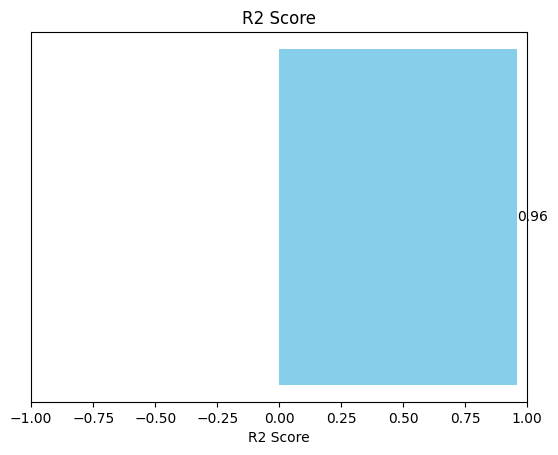

In [89]:
# Plotting the R2 score
fig, ax = plt.subplots()
ax.barh(0, r2, color='skyblue')
ax.set_xlim([-1, 1])
ax.set_yticks([])
ax.set_xlabel('R2 Score')
ax.set_title('R2 Score')

# Adding the R2 score value on the bar
ax.text(r2, 0, f'{r2:.2f}', va='center', color='black')

plt.show()

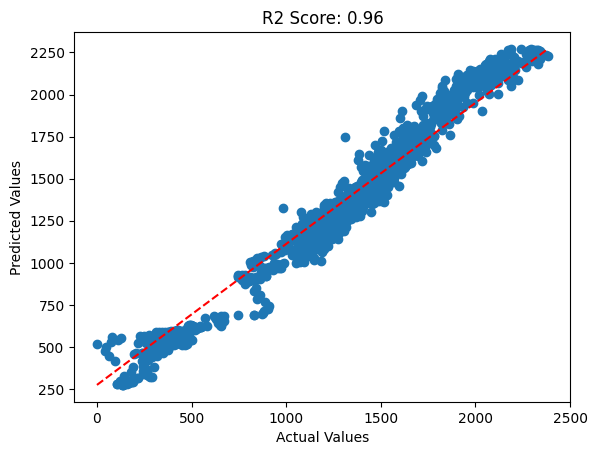

In [90]:
plt.scatter(actual, predicted)
plt.plot([min(actual), max(actual)], [min(predicted), max(predicted)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'R2 Score: {r2:.2f}')
plt.show()